In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import pymc as pm
import os
import arviz as az
import matplotlib.pyplot as plt

%matplotlib inline

## Variables

| Symbol | Description | Type |
| :---   | :---        | :--- |
| $W_{it}$ | Willingness-to-pay of household $i$ in year $t$ | Latent |
| $P_{it}$ | Insurance premium of household $i$ in year $t$ | Observed |
| $x_{it}$ | Covariate affecting WTP (e.g., recent flood exposure) | Observed |
| $\alpha_{i}$  | Stable, household-specific baseline WTP | Latent |
| $\epsilon_{it}$  | Idiosyncratic, time-varying shocks to WTP (e.g., income shocks, life events) | Latent |
| $R_{it}$  | Binary variable denoting whether household $i$ renewed their policy for year $t$ | Observed |
| $\delta_{it}$ | Binary variable denoting whether household $i$ discontinued their policy for reasons unrelated to price (exogenous churn) | Latent |

## Data Generating Process

$$ \ln \left( W_{it} \right) = \alpha_i + \beta x_{it} + \epsilon_{it}$$

$$ \epsilon_{it} \sim \mathcal{N}(0, \sigma_{\epsilon}^2)$$

$$ \alpha_{i} \sim \mathcal{N}(\mu_{\alpha}, \sigma_{\alpha}^2)$$

$$ R_{it} = (1 - \delta_{it}) \cdot \mathbb{1}(W_{it} > P_{it})  $$

$$ \delta_{it} \sim \text{Bernoulli}(p_{\delta}) $$

## Simplifying Assumptions

- For now, assume that $W_{it}$ is independent of $P_{it}$. This assumption simplifies the math but is not very realistic: in reality, household's WTP is likely to be positively correlated with their flood insurance premium, as both variables are affected by underlying flood risk. Eventually, we'll likely want to incorporate this statistical dependence into our model of the data generating process.

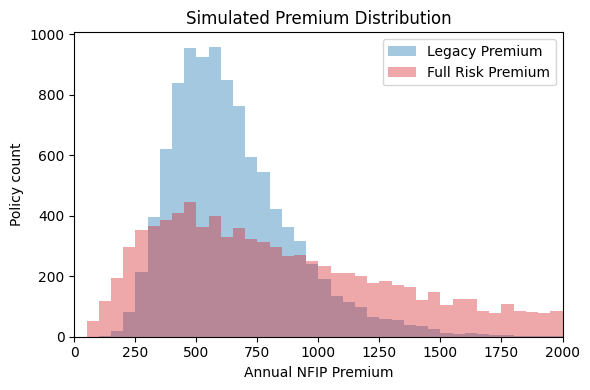

In [2]:
### *** PREMIUM DISTRIBUTION *** ###

# Set random seed for reproducibility
seed = 112263
np.random.seed(seed)

# Number of simulated policyholders
N = 10000

# Legacy premium values
# (Simulate from lognormal distribution with specified median / IQR) 
Q1 = 450
Q2 = 600
Q3 = 750
IQR = np.log(Q3)-np.log(Q1)
mu = np.log(Q2)
sigma = IQR/(2*stats.norm.ppf(0.75))
legacy_premium = np.exp(stats.norm(loc=mu,scale=sigma).rvs(N))

# Full risk premium values
Q1 = 500
Q2 = 850
Q3 = 1500
IQR = np.log(Q3)-np.log(Q1)
mu = np.log(Q2)
sigma = IQR/(2*stats.norm.ppf(0.75))
fullrisk_premium = np.exp(stats.norm(loc=mu,scale=sigma).rvs(N))

fig,ax = plt.subplots(figsize=(6,4))
ax.hist(legacy_premium,bins=np.arange(0,3000,50),alpha=0.4,color='C0',label='Legacy Premium')
ax.hist(fullrisk_premium,bins=np.arange(0,3000,50),alpha=0.4,color='C3',label='Full Risk Premium')
ax.set_xlim([0,2000])
ax.set_xlabel('Annual NFIP Premium')
ax.set_ylabel('Policy count')
ax.set_title('Simulated Premium Distribution')
ax.legend()
fig.tight_layout()
fig.show()

In [3]:
### *** WTP PARAMETERS *** ###

# Stable, baseline WTP
mu_alpha = 6.4
sigma_alpha = 1.0

# Time-varying shocks to WTP
sigma_epsilon = 0.08

# Effect of covariate X on WTP
beta = 0.2

# Exogenous churn
p_delta = 0.15

In [4]:
### *** DATA GENERATING PROCESS *** ###

def rr2_glidepath(legacy_premium,fullrisk_premium,T):
    """
    This function simulates the gradual phase-in of full-risk premiums under risk rating 2.0, 
    with annual rate increases capped at a maximum of 18% per year. 

    param: legacy_premium: Legacy premium (price paid in year 0)
    param: fullrisk_premium: Full-risk premium
    param: T: Number of years to simulate phase-in of full-risk premiums
    """

    P = np.zeros(T)
    P[0] = legacy_premium
    
    for t in range(1,T):
        
        P[t] = P[t-1]*min(fullrisk_premium/P[t-1],1.18)

    return P

def simulate_wtp(legacy_premium,fullrisk_premium,id=1,T=5):
    """
    This function simulates the renewal decisions of an individual policyholder over time 
    based on his/her time-varying flood insurance premium and willingness-to-pay. 

    param: legacy_premium: Legacy premium (price paid in year 0)
    param: fullrisk_premium: Full-risk premium
    param: id: integer denoting policyholder id
    param: T: Number of years to simulate policyholder renewal decisions
    """

    # Calculate premium in each year under risk rating 2.0 
    P = rr2_glidepath(legacy_premium,fullrisk_premium,T)

    # Simulate time-varying WTP shocks
    epsilon = stats.norm(loc=0,scale=sigma_epsilon).rvs(T)

    # Simulate value of covariate affecting WTP (observed)
    x = stats.bernoulli(0.1).rvs(T)

    # Simulate exogenous churn
    delta = stats.bernoulli(p_delta).rvs(T)
    delta[0] = 0

    # Calculate lower bound on alpha
    # (we know that ln(WTP) > ln(P) in year zero given that they bought a policy)
    LB = np.log(P[0]) - beta*x[0] - epsilon[0]

    # Simulate alpha (latent)
    # (If alpha and P are independent, then conditional distribution is truncated normal)
    a = (LB - mu_alpha) / sigma_alpha
    cond_dist = stats.truncnorm(a=a, b=np.inf, loc=mu_alpha, scale=sigma_alpha)
    alpha = cond_dist.rvs()

    # Simulate WTP in each year (latent) 
    W = np.exp(alpha + beta*x + epsilon)

    # Simulate renewal decision (observed)
    R = (1-delta)*(W > P)

    # Create dataframe
    data = {'id':id,
            't':np.arange(T),
            'P':P,
            'W':W,
            'log_P':np.log(P),
            'log_W':np.log(W),
            'alpha':alpha,
            'exp_alpha':np.exp(alpha),
            'x':x,
            'epsilon':epsilon,
            'delta':delta,
            'R':R}

    df = pd.DataFrame(data)

    # Drop observations occurring after a policyholder fails to renew
    # (these policyholders are lost to follow-up in our data) 
    mask = (df['R'] == 0).cummax().shift(fill_value=False)
    df = df[~mask]

    return df

In [5]:
### *** SIMULATE DATASET *** ###

sim_df = pd.concat([simulate_wtp(legacy_premium[i],fullrisk_premium[i],id=i+1) for i in range(N)]).reset_index(drop=True)
sim_df

,id,t,P,W,log_P,log_W,alpha,exp_alpha,x,epsilon,delta,R
0,1,0,732.958307,838.283846,6.597089,6.731357,6.720937,829.594405,0,0.010420,0,1
1,1,1,317.319812,993.500979,5.759910,6.901235,6.720937,829.594405,0,0.180298,0,1
2,1,2,317.319812,856.234213,5.759910,6.752544,6.720937,829.594405,0,0.031607,0,1
3,1,3,317.319812,851.982818,5.759910,6.747566,6.720937,829.594405,0,0.026629,0,1
4,1,4,317.319812,814.941193,5.759910,6.703116,6.720937,829.594405,0,-0.017821,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
38854,9999,4,628.984597,2124.715788,6.444107,7.661393,7.797240,2433.874332,0,-0.135846,0,1
38855,10000,0,414.081515,569.344833,6.026063,6.344486,6.454381,635.479962,0,-0.109894,0,1
38856,10000,1,488.616188,609.774585,6.191577,6.413089,6.454381,635.479962,0,-0.041291,0,1
38857,10000,2,576.567101,654.735370,6.357092,6.484231,6.454381,635.479962,0,0.029851,0,1
